Today's topics:
* writing a function with `def`
* calling it
* `print` versus `return`
* positional arguments, where order matters
* checking a function on a case with a known answer

# Unit cell volume

A lithium all-solid-state battery replaces the conventional flammable liquid electrolyte with a solid ion conductor.
Today's dataset is a collection of inorganic solid electrolytes.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/93/U.S._Department_of_Energy_-_Science_-_395_011_003_%289474983500%29.jpg/960px-U.S._Department_of_Energy_-_Science_-_395_011_003_%289474983500%29.jpg" alt="A thin white ceramic disc, about the size of a coin, held between two fingers" width=360/>

*Photo by the U.S. Department of Energy, public domain, [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:U.S._Department_of_Energy_-_Science_-_395_011_003_(9474983500).jpg).*

Above: A thin [beta-alumina](https://en.wikipedia.org/wiki/Beta-alumina_solid_electrolyte) membrane made for a planar sodium battery.
Beta-alumina is a ceramic electrolyte that conducts sodium ions.
EaglePicher and Pacific Northwest National Laboratory developed the battery design.

The electrolytes in our data conduct lithium ions.

<img src="https://upload.wikimedia.org/wikipedia/commons/c/c4/All-Solid-State_Battery.png" alt="A diagram of a solid-state battery: a grey anode on the left, a green solid electrolyte layer in the middle, and a tan cathode on the right, with a light bulb wired across the top" width=360/>

*Diagram by Luca Bertoli, [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/), [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:All-Solid-State_Battery.png).*

Above: A [solid-state battery](https://en.wikipedia.org/wiki/Solid-state_battery). The solid electrolyte (green) sits between the anode and the cathode.

Most ceramics conduct lithium ions poorly.
A commonly quoted room-temperature target for a solid electrolyte is $10^{-3}$ S/cm.

How well a structure conducts depends on where the lithium can sit, whether those sites
connect into a path, and how much energy each hop costs.

Unit cell volume is one descriptor we can compute from the lattice parameters in these records.
It measures the cell size.

So how do we turn six lattice parameters into a unit cell volume for every electrolyte?

A general cell volume uses all six lattice parameters.

$$V = abc\sqrt{1 - \cos^2\alpha - \cos^2\beta - \cos^2\gamma + 2\cos\alpha\cos\beta\cos\gamma}$$

The [OBELiX dataset](https://github.com/NRC-Mila/OBELiX) contains 599 synthesized lithium solid electrolytes with measured room-temperature ionic conductivities (Therrien et al. 2026, [Digital Discovery](https://doi.org/10.1039/D5DD00441A)).
Every record lists six lattice parameters. Of these, 321 also include a full crystal structure as a CIF.
We'll load twelve records to work with by hand.

In [1]:
#@title Load solid electrolyte structures and conductivities (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import pandas as pd

_file = 'obelix_electrolytes.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}',
                 f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    _table = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

_table.columns = [c.strip() for c in _table.columns]
_ok = _table.dropna(subset=['a', 'b', 'c', 'alpha', 'beta', 'gamma'])

cells = []
for _, _row in _ok.head(12).iterrows():
    cells.append({
        'composition': _row['Composition'],
        'a': float(_row['a']), 'b': float(_row['b']), 'c': float(_row['c']),
        'alpha': float(_row['alpha']), 'beta': float(_row['beta']), 'gamma': float(_row['gamma']),
        'sigma': float(_row['Ionic conductivity (S cm-1)']),
    })

sigma_all = _table['Ionic conductivity (S cm-1)'].to_numpy()

print(f'Loaded {len(_table)} solid electrolytes from {_file}')
print(f'  cells:     {len(cells)} records with lattice parameters and conductivity')
print(f'  sigma_all: {len(sigma_all)} conductivities, {sigma_all.min():.1e} to {sigma_all.max():.1e} S/cm')

Loaded 599 solid electrolytes from obelix_electrolytes.csv
  cells:     12 records with lattice parameters and conductivity
  sigma_all: 599 conductivities, 4.2e-18 to 2.5e-02 S/cm


> `np.cos` and `np.radians` are new. We copy them as a recipe today, like L06's histogram.
> `np.cos` takes radians, and `np.radians` converts degrees to radians.

# Writing it out

Let's write out the volume of the first electrolyte.

In [2]:
import numpy as np

first = cells[0]
ca = np.cos(np.radians(first['alpha']))
cb = np.cos(np.radians(first['beta']))
cg = np.cos(np.radians(first['gamma']))
v = first['a'] * first['b'] * first['c'] * np.sqrt(1 - ca**2 - cb**2 - cg**2 + 2 * ca * cb * cg)
print(v)

133.95911644245365


Five lines for one volume.
Copy them for the second electrolyte, changing every `first` to `second`.

In [3]:
second = cells[1]
ca = np.cos(np.radians(second['alpha']))
cb = np.cos(np.radians(second['beta']))
cg = np.cos(np.radians(first['gamma']))
v = second['a'] * second['b'] * second['c'] * np.sqrt(1 - ca**2 - cb**2 - cg**2 + 2 * ca * cb * cg)
print(v)

126.99774716510095


Every line of that cell is valid Python.
Line three still uses `first['gamma']` and leaves the volume off by less than half a percent.
Twelve copies would leave twelve chances for an old value to stay behind.

# def

Functions are self-contained pieces of code that we can reuse.
We've already used plenty of them, like `np.mean` and `plt.plot`.
How do we write our own?
With `def`:

In [4]:
# def is the python keyword
# my_function is the name
# arg is a parameter
def my_function(arg):
    # do something with the argument
    print(arg)
    # the extent is indicated by indent

In [5]:
# 'hello' is the argument in this call
out = my_function('hello')

hello


The line starting with `def` holds the name and the inputs in parentheses, and it ends with a colon.
The indented block below it is the body, the same shape as the `for` and `if` blocks from L15.

The `def` statement stores the function definition.
Nothing in the body runs until the call.

# print and return

The call to `my_function` printed `hello`.
What value does the call have?
Let's store it in `out` and look.

In [6]:
out = my_function('hello')
print(out)

hello
None


`None` is Python's word for no value.
`print` also returns `None`.

In [7]:
out = print('hello')
print(out)

hello
None


Use `return` when the call needs a value:

In [8]:
def my_function(arg):
    arg_plus = arg + ' from my_function'
    print(arg_plus)
    return arg_plus  # this becomes the value of the call

out = my_function('hello')  # out is set to arg_plus
print(out)

hello from my_function
hello from my_function


A `return` statement ends the call.
The value after `return` becomes the value of the call.

## The unit cell function

We'll give the volume calculation a name and list its parameters.
The body is the same calculation as before, ending in a `return`.

In [9]:
def cell_volume(a, b, c, alpha, beta, gamma):
    ca = np.cos(np.radians(alpha))
    cb = np.cos(np.radians(beta))
    cg = np.cos(np.radians(gamma))
    return a * b * c * np.sqrt(1 - ca**2 - cb**2 - cg**2 + 2 * ca * cb * cg)

The six inputs in parentheses are the function's **parameters**.
Inside the body we use them as variables.

# Calling it

We can now replace the five calculation lines with one call and store the value it returns.

In [10]:
v1 = cell_volume(5.5071, 6.0425, 5.5231, 116.912, 120.867, 62.234)
print(v1)

133.95911644245365


The values in the call are the **arguments**.

# Positional arguments

Python matches arguments to parameters by position.
A two-parameter toy makes the matching visible.

In [11]:
def my_function(a, b):
    return (a + 1) * b

print(my_function(1, 2))  # a = 1, b = 2
print(my_function(2, 1))  # a = 2, b = 1

4
3


Reversing the two arguments changes which value is assigned to `a` and which to `b`.
The toy then returns a different result.

`cell_volume` has six parameters.
Each physical quantity must be matched to the intended parameter.
What happens if we swap `c` and `gamma`?

In [12]:
print(cell_volume(5.5071, 6.0425, 62.234, 116.912, 120.867, 5.5231))  # c and gamma swapped

121.74797669551997


The result is a plausible volume computed from the wrong inputs.

Naming each key makes the order easier to check.

In [13]:
print(cell_volume(first['a'], first['b'], first['c'],
                  first['alpha'], first['beta'], first['gamma']))

133.95911644245365


# Checking it

A cube of side 4 with all three angles at 90 degrees has a volume of 64.

In [14]:
print(cell_volume(4, 4, 4, 90, 90, 90))

64.0


Every cosine is zero.
The cube tests the three-length product by itself.

### [Check your understanding]

The cube leaves the cosine terms untested.
An edge-1 cell with all three angles at 60 degrees has three cosines of 0.5.
Its volume is $\sqrt{1 - 0.75 + 0.25} = \sqrt{0.5} = 0.7071$.

Call `cell_volume` on that cell and check that you get 0.7071.

# Every electrolyte

With the loop from L15, each volume costs one line of calling.
The loop applies the function to every record and keeps each volume in a list.

In [15]:
volumes = []
for cell in cells:
    v = cell_volume(cell['a'], cell['b'], cell['c'],
                    cell['alpha'], cell['beta'], cell['gamma'])
    volumes.append(v)
    print(f"{cell['composition']:24s} {v:8.1f} A^3")

Li7.0Bi1.0O6.0              134.0 A^3
Li7.0Sb1.0O6.0              127.5 A^3
Li2.0V2.0P2.0O8.0F2.0       174.6 A^3
Li6.0B2.0P4.0O16.0          279.1 A^3
Li4.0Na2.0B2.0P4.0O16.0     294.0 A^3
Li8.0P4.0O14.0              285.1 A^3
Li6.0Cu1.0B4.0O10.0         201.1 A^3
Li14.0P6.0S22.0             829.3 A^3
Li5.46Hf12.13P18.0O72.0    1487.5 A^3
Li14.0P6.0S22.0             824.5 A^3
Li24.0Bi8.0O24.0            701.6 A^3
Li10.0Bi2.0O10.0            232.2 A^3


Now we have one definition of the formula.
Fixing it once updates every call.

Each record also has a measured conductivity.
We plot the volumes against the base-10 log of the conductivity (L15), with the $10^{-3}$ S/cm target as a dashed line (L10).

Text(0, 0.5, 'log10 ionic conductivity (log10 S/cm)')

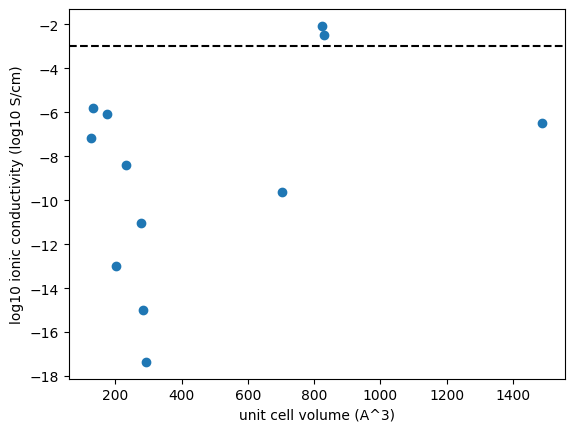

In [16]:
import matplotlib.pyplot as plt

log_sigma = [np.log10(cell['sigma']) for cell in cells]

fig, ax = plt.subplots()
ax.scatter(volumes, log_sigma)
ax.axhline(-3, color='black', linestyle='--')  # the 1e-3 S/cm target
ax.set_xlabel('unit cell volume (A^3)')
ax.set_ylabel('log10 ionic conductivity (log10 S/cm)')

These twelve points show no clear relationship between unit cell volume and conductivity.

If you knew only a cell's volume, how well could you guess its conductivity?

### [Check your understanding]

The density of a cubic crystal is the mass of the atoms in one cell divided by the
volume of that cell. Write a function `cubic_density(a, atoms_per_cell, mass_amu)`.
Here `a` is the edge length in angstroms and `mass_amu` is the mass of one atom in amu.
Return `atoms_per_cell * mass_amu / a**3 * 1.66054` in g/cm³.

Test copper with `print(cubic_density(3.615, 4, 63.546))`. The result should be near 8.9.

Test aluminum with `print(cubic_density(4.050, 4, 26.98))`. The result should be near 2.70.

*The factor 1.66054 converts amu/Å³ to g/cm³.*

# Summary

* `def name(parameters):` stores a recipe under a name. The body runs at each call.
* A call supplies arguments. They pair with the parameters by position.
* A function with no explicit `return` has the value `None`. A `return` value becomes the value of the call.
* `print` displays a value on screen. `return` makes a value available to later code.
* A function is checked on a case whose answer is known, such as the cube.
* The volume formula is written once. A loop applies it to every record.

## Further reading

* VanderPlas, *A Whirlwind Tour of Python*, "Defining and Using Functions"
* The data: Therrien et al., "OBELiX: a curated dataset of crystal structures and experimentally measured ionic conductivities for lithium solid-state electrolytes," *Digital Discovery* 5 (2026) 910-918, [DOI 10.1039/D5DD00441A](https://doi.org/10.1039/D5DD00441A). [Dataset repository](https://github.com/NRC-Mila/OBELiX), CC BY 4.0
* Photo credit: beta-alumina membrane, U.S. Department of Energy, public domain, [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:U.S._Department_of_Energy_-_Science_-_395_011_003_(9474983500).jpg)
* Diagram credit: "All-Solid-State Battery" by Luca Bertoli, [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/), [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:All-Solid-State_Battery.png)